# Phase 1 — Exploratory Data Analysis (AppleSupport conversations, twcs)

This notebook is the **Phase 1 EDA** of the *Apple Support AI — Evidence-Grounded Customer Support Agent* project (assignment §6). It reads **only the processed Phase 1 outputs** of `scripts/prepare_data.py`, which has already run end-to-end on the real Kaggle `twcs.csv` (2,811,774 tweets, 516,508,641 bytes). The raw 516 MB file is never re-downloaded or re-processed here.

| Processed file | Content |
|---|---|
| `data/processed/pipeline_run.json` | run metadata — scan stats, cleaning report, reconstruction stats, stages, validations |
| `data/processed/applesupport_tweets.csv` | every tweet belonging to an AppleSupport conversation |
| `data/processed/conversations.csv` | one row per reconstructed conversation |
| `data/processed/conversation_pairs.csv` | customer message ↔ historical AppleSupport reply pairs |
| `data/processed/eda_summary.json` | contract summary written by `scripts/run_eda.py` (used only for the final cross-check) |

> **Historical-data disclaimer.**
> The dataset contains historical customer-support interactions. Historical AppleSupport responses are evidence for retrieval and evaluation, not a representation of current Apple policies.

**Methodology & reproducibility**

- The analysis logic is **equivalent to `scripts/run_eda.py`** — the same `STOPWORDS`, `PROVISIONAL_TOPICS` keyword lists, tokenizer and histogram buckets are copied into the notebook so it is self-contained. Section 11 cross-checks every headline number against the pipeline's contract file `data/processed/eda_summary.json`.
- Every number quoted in the markdown commentary is computed by the code cells of this notebook (the same deterministic computation that produced `eda_summary.json`).
- `SEED = 42` (the project's `random_seed`) is used only for the sample-conversation selection; everything else is deterministic.
- Environment: Python 3 kernel with pandas / NumPy / matplotlib / seaborn; all plots render inline.

**Contents**

1. Setup — imports, style, repository paths
2. Constants & helpers (mirrored from `scripts/run_eda.py`)
3. Load the processed outputs — provenance & pipeline stages
4. Dataset scale — the raw scan vs the AppleSupport corpus
5. Inbound vs outbound distribution
6. Conversations & thread-length distribution
7. Message-length statistics
8. Terms & bigrams in customer messages
9. Provisional support topics (keyword tagging)
10. Multi-topic customer messages
11. Evidence in practice — sample conversations
12. Cross-check against `scripts/run_eda.py` (`eda_summary.json`)
13. Implications for the Phase 2 intent taxonomy

## 1. Setup

Imports, plotting style and repository paths. The root finder works whether the kernel starts in the repository root, in `notebooks/`, or in the parent workspace directory — it simply looks for `data/processed/pipeline_run.json`.

In [1]:
%matplotlib inline

import json
import re
import textwrap
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Project style: seaborn theme + the emerald accent used across the project.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

ACCENT = "#10b981"   # emerald — primary series / AppleSupport
NEUTRAL = "#a1a1aa"  # zinc — secondary series

SEED = 42  # project random_seed (src.config) — used only for sampling below


def find_repo_root() -> Path:
    """Locate the repository root that contains data/processed/pipeline_run.json."""
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents, here / "hiver-support-agent"]:
        if (candidate / "data" / "processed" / "pipeline_run.json").is_file():
            return candidate
    raise FileNotFoundError(
        "data/processed/pipeline_run.json not found — start this notebook from "
        "the repository root (or notebooks/) after running scripts/prepare_data.py"
    )


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "processed"

INPUTS = {
    "pipeline_run.json": "run metadata: scan stats, cleaning report, stages, validations",
    "applesupport_tweets.csv": "every tweet in AppleSupport conversations",
    "conversations.csv": "one row per reconstructed conversation",
    "conversation_pairs.csv": "customer message <-> historical support reply pairs",
    "eda_summary.json": "contract summary from scripts/run_eda.py (cross-check only)",
}

print(f"Repository root : {REPO_ROOT}")
print(f"Data directory  : {DATA_DIR}\n")
for name, description in INPUTS.items():
    path = DATA_DIR / name
    print(f"  {name:26s} {path.stat().st_size / 1e6:8.1f} MB   {description}")

Repository root : /home/z/my-project/hiver-support-agent
Data directory  : /home/z/my-project/hiver-support-agent/data/processed

  pipeline_run.json               0.0 MB   run metadata: scan stats, cleaning report, stages, validations
  applesupport_tweets.csv        42.5 MB   every tweet in AppleSupport conversations
  conversations.csv               8.0 MB   one row per reconstructed conversation
  conversation_pairs.csv         36.6 MB   customer message <-> historical support reply pairs
  eda_summary.json                0.0 MB   contract summary from scripts/run_eda.py (cross-check only)


## 2. Constants & helpers (mirrored from `scripts/run_eda.py`)

Two constant groups are copied **verbatim** from `scripts/run_eda.py` so the notebook is self-contained and its numbers directly comparable:

1. **Display stopwords** — standard English function words plus conversational filler with no topical signal. They are applied *only* to the term-frequency counts; the customer wording itself is never modified.
2. **Provisional keyword topics** — deliberately broad, transparent whole-word keyword matching over raw customer messages (e.g. `app` must not match inside `apple`). The observed frequencies *inform* the Phase 2 intent taxonomy; this is **not** the Phase 2 classifier.

In [2]:
# Display stopwords (copied verbatim from scripts/run_eda.py).
STOPWORDS = frozenset({
    "the", "and", "for", "are", "but", "not", "you", "your", "youre", "youve",
    "with", "that", "this", "have", "from", "they", "them", "their", "there",
    "here", "what", "when", "where", "which", "while", "will", "just", "would",
    "could", "should", "than", "then", "been", "being", "were", "was", "has",
    "had", "does", "did", "doing", "into", "onto", "over", "under", "again",
    "more", "most", "some", "such", "only", "very", "much", "many", "also",
    "because", "about", "after", "before", "between", "through", "during",
    "above", "below", "both", "each", "few", "other", "same", "such", "only",
    "own", "too", "can", "cant", "cannot", "how", "why", "who", "whom", "its",
    "it's", "im", "ive", "id", "ill", "my", "me", "we", "our", "ours", "us",
    "he", "him", "his", "she", "her", "hers", "get", "got", "getting", "go",
    "going", "want", "wants", "need", "needs", "like", "know", "really",
    "still", "even", "ever", "never", "always", "please", "pls", "plz",
    "thanks", "thank", "thx", "hey", "hi", "hello", "sorry", "help", "back",
    "one", "two", "get", "got", "let", "lets", "try", "tried", "trying",
    "see", "look", "looks", "way", "thing", "things", "stuff", "anyone",
    "anybody", "someone", "somebody", "guys", "via", "dm", "pms",
    "now", "all", "any", "anything", "something", "nothing", "everything",
    "else", "again", "without", "within", "per",
})

print(f"{len(STOPWORDS)} display stopwords loaded (term counting only)")

158 display stopwords loaded (term counting only)


In [3]:
# Provisional keyword topics (copied verbatim from scripts/run_eda.py).
PROVISIONAL_TOPICS: dict[str, tuple[str, ...]] = {
    "Account / Apple ID": (
        "apple id", "password", "passcode", "sign in", "sign-in", "login",
        "log in", "log-in", "account", "verification code", "verify",
        "two factor", "2fa",
    ),
    "iCloud / Backup": (
        "icloud", "backup", "back up", "backed up", "cloud", "sync",
        "storage full", "restore",
    ),
    "Billing / Payments": (
        "bill", "billing", "charge", "charged", "payment", "card", "invoice",
        "receipt", "credit", "double charg", "overcharg",
    ),
    "Refunds / Purchases": (
        "refund", "money back", "purchase", "bought", "paid", "in-app",
        "in app", "app store purchase",
    ),
    "Subscriptions": (
        "subscription", "subscribe", "apple music", "apple tv", "applecare",
        "trial", "renewal", "renew",
    ),
    "Device / Hardware": (
        "screen", "battery", "crack", "broke", "broken", "button", "water",
        "camera", "speaker", "microphone", "charger", "charging port",
        "headphone", "drop", "dropped", "dead", "wont turn on", "won't turn on",
        "black screen",
    ),
    "Software / Apps": (
        "update", "updated", "upgrade", "ios", "ipados", "macos", "bug",
        "glitch", "crash", "crashing", "frozen", "froze", "freeze", "hang",
        "stuck", "app", "reset", "reboot", "restart",
    ),
    "Connectivity": (
        "wifi", "wi-fi", "wi fi", "network", "internet", "bluetooth", "pair",
        "connect", "connection", "signal", "cellular", "hotspot", "airdrop",
    ),
    "Repair / Warranty": (
        "warranty", "repair", "replace", "replacement", "genius bar",
        "genius", "service", "out of warranty",
    ),
    "Order / Delivery": (
        "order", "delivery", "deliver", "ship", "shipping", "shipped",
        "tracking", "track", "arrive", "package", "parcel", "dispatch",
    ),
    "Security / Privacy": (
        "phishing", "scam", "fraud", "hack", "hacked", "hacker", "stolen",
        "steal", "stole", "compromised", "suspicious", "fake email",
        "fake text", "spam", "privacy",
    ),
}

print(f"{len(PROVISIONAL_TOPICS)} provisional topics, "
      f"{sum(len(keys) for keys in PROVISIONAL_TOPICS.values())} keywords in total")

11 provisional topics, 134 keywords in total


In [4]:
# Analysis constants — identical to scripts/run_eda.py.
TERMS_TOP_N = 15            # top unigrams shown
BIGRAMS_TOP_N = 10          # top bigrams shown
CONV_HIST_MAX_TURNS = 20    # conversations with >= 20 tweets grouped into one bucket
MESSAGE_BUCKETS: list[tuple[str, int, int | None]] = [
    ("1-25", 1, 25),
    ("26-50", 26, 50),
    ("51-75", 51, 75),
    ("76-100", 76, 100),
    ("101-150", 101, 150),
    ("151-200", 151, 200),
    ("201+", 201, None),
]


def tokenize(text: str) -> list[str]:
    """Lower-cased alphabetic tokens (length >= 3) — for term counting only."""
    return [tok for tok in
            (t.strip(".,!?;:'\"()[]{}…—-") for t in text.lower().split())
            if len(tok) >= 3 and tok.isalpha()]


def term_frequencies(messages: pd.Series) -> tuple[list[dict], list[dict]]:
    """Top unigrams and bigrams over display-stopword-filtered tokens."""
    unigrams: Counter = Counter()
    bigrams: Counter = Counter()
    for message in messages:
        tokens = [t for t in tokenize(message) if t not in STOPWORDS]
        unigrams.update(tokens)
        bigrams.update(zip(tokens, tokens[1:]))
    top_terms = [{"term": t, "count": int(c)}
                 for t, c in unigrams.most_common(TERMS_TOP_N)]
    top_bigrams = [{"term": " ".join(pair), "count": int(c)}
                   for pair, c in bigrams.most_common(BIGRAMS_TOP_N)]
    return top_terms, top_bigrams


def provisional_topics(messages: pd.Series):
    """Keyword-topic tagging — matching logic identical to scripts/run_eda.py.

    Keywords match on word boundaries; phrases match as whole phrases.
    Extended (vs. run_eda.py) to also return the multi-topic count, the
    per-message topic-count histogram and topic co-occurrence counts — all
    derived in the same single pass.
    """
    total = len(messages)
    compiled = {
        topic: [re.compile(r"\b" + re.escape(key) + r"\b") for key in keys]
        for topic, keys in PROVISIONAL_TOPICS.items()
    }
    matched_counts: Counter = Counter()
    co_occurrence: Counter = Counter()
    topic_count_hist: Counter = Counter()
    multi = 0
    for message in messages:
        hits = [topic for topic, patterns in compiled.items()
                if any(p.search(message) for p in patterns)]
        if hits:
            matched_counts.update(hits)
            if len(hits) >= 2:
                multi += 1
                for i in range(len(hits)):
                    for j in range(i + 1, len(hits)):
                        co_occurrence[tuple(sorted((hits[i], hits[j])))] += 1
        topic_count_hist[min(len(hits), 4)] += 1
    topics = [
        {
            "topic": topic,
            "matched": int(matched_counts.get(topic, 0)),
            "share": round(matched_counts.get(topic, 0) / total, 4) if total else 0.0,
        }
        for topic in PROVISIONAL_TOPICS
    ]
    topics.sort(key=lambda item: item["matched"], reverse=True)
    multi_share = round(multi / total, 4) if total else 0.0
    return topics, multi, multi_share, topic_count_hist, co_occurrence


def conversation_length_histogram(conversations: pd.DataFrame) -> list[dict]:
    """Tweet-count-per-conversation histogram (tail aggregated at 20+)."""
    counts = conversations["tweets"].astype(int)
    histogram: list[dict] = []
    for turns in range(1, CONV_HIST_MAX_TURNS + 1):
        if turns == CONV_HIST_MAX_TURNS:
            bucket = int((counts >= turns).sum())
        else:
            bucket = int((counts == turns).sum())
        if bucket or turns < 3:  # always show the head, even if zero
            histogram.append({"turns": turns, "count": bucket})
    return histogram


def message_length_histogram(texts: pd.Series) -> list[dict]:
    """Character-length histogram over the bucket grid used by run_eda.py."""
    lengths = texts.astype(str).str.len()
    histogram: list[dict] = []
    for label, low, high in MESSAGE_BUCKETS:
        if high is None:
            count = int((lengths >= low).sum())
        else:
            count = int(((lengths >= low) & (lengths <= high)).sum())
        histogram.append({"bucket": label, "count": count})
    return histogram


def sample_conversations(pairs: pd.DataFrame, conversations: pd.DataFrame,
                         seed: int, n: int = 6) -> list[dict]:
    """Deterministically pick sample pairs stratified by conversation size."""
    merged = pairs.merge(
        conversations[["conversation_id", "tweets"]],
        on="conversation_id", how="left",
    )
    merged = merged.sort_values("conversation_id", kind="mergesort").reset_index(drop=True)
    turns = merged["tweets"].fillna(merged["turn"].astype(float))
    short = merged[turns <= 3]
    medium = merged[(turns > 3) & (turns <= 8)]
    long_ = merged[turns > 8]
    samples: list[pd.Series] = []
    rng = pd.Series(range(len(merged))).sample(frac=1.0, random_state=seed)  # deterministic shuffle key
    shuffled = merged.iloc[rng.index]
    for pool, take in ((short, 2), (medium, 2), (long_, 2)):
        pool_shuffled = shuffled[shuffled["conversation_id"].isin(pool["conversation_id"])]
        chosen = pool_shuffled.drop_duplicates("conversation_id").head(take)
        samples.extend(chosen.to_dict("records"))
    out: list[dict] = []
    seen: set = set()
    for record in samples:
        if record["conversation_id"] in seen:
            continue
        seen.add(record["conversation_id"])
        out.append({
            "conversation_id": str(record["conversation_id"]),
            "turns": int(record["tweets"]) if pd.notna(record["tweets"]) else int(record["turn"]),
            "created_at": str(record["created_at"]),
            "customer_message": str(record["customer_message"]),
            "support_response": str(record["support_response"]),
        })
        if len(out) >= n:
            break
    return out


print("Helpers ready — analysis logic mirrors scripts/run_eda.py")

Helpers ready — analysis logic mirrors scripts/run_eda.py


## 3. Load the processed Phase 1 outputs

Raw-dataset statistics come from `pipeline_run.json → scan_stats` (computed over the whole 2.8 M-tweet file while the pipeline ran); everything else is recomputed here from the three processed CSVs.

In [5]:
run_report = json.loads((DATA_DIR / "pipeline_run.json").read_text(encoding="utf-8"))
tweets = pd.read_csv(DATA_DIR / "applesupport_tweets.csv", dtype=str, keep_default_na=False)
tweets["inbound"] = tweets["inbound"].astype(str).str.lower().eq("true")
conversations = pd.read_csv(DATA_DIR / "conversations.csv", dtype=str, keep_default_na=False)
conversations["tweets"] = conversations["tweets"].astype(int)
pairs = pd.read_csv(DATA_DIR / "conversation_pairs.csv", dtype=str, keep_default_na=False)
timestamps = pd.to_datetime(tweets["created_at"], format="mixed", errors="coerce", utc=True)

inp = run_report["input"]
n_passed = sum(v["passed"] for v in run_report["validations"])
print(f"Run generated   : {run_report['generated_at']}  (phase {run_report['phase']}, mode = {run_report['mode']})")
print(f"Source dataset  : {inp['file']} — {inp['size_bytes']:,} bytes (synthetic = {inp['synthetic']})")
print(f"Support author  : {run_report['apple_support_author_id']}")
print(f"Pipeline run    : {run_report['duration_seconds']} s — {n_passed}/{len(run_report['validations'])} structural validations passed\n")

print("Processed outputs on disk:")
display(pd.DataFrame(
    [{"processed file": name, "rows": f"{info['rows']:,}"}
     for name, info in run_report["outputs"].items()]
))

print("Cleaning report (conservative text cleaning, per-tweet counts):")
display(pd.DataFrame(
    [{"cleaning metric": key.replace("_", " "), "value": f"{value:,}"}
     for key, value in run_report["cleaning_report"].items()]
))

print(f"Loaded into memory : tweets {tweets.shape[0]:,} x {tweets.shape[1]} cols | "
      f"conversations {len(conversations):,} | pairs {len(pairs):,}")
print(f"Timestamp span     : {timestamps.min():%Y-%m-%d} to {timestamps.max():%Y-%m-%d} "
      f"(10th-90th percentile: {timestamps.quantile(0.10):%Y-%m-%d} to {timestamps.quantile(0.90):%Y-%m-%d})")

Run generated   : 2026-09-10 07:51:48 UTC  (phase 1, mode = full)
Source dataset  : twcs.csv — 516,508,641 bytes (synthetic = False)
Support author  : AppleSupport
Pipeline run    : 211.8 s — 7/7 structural validations passed

Processed outputs on disk:


,processed file,rows
0,applesupport_tweets.csv,"237,745"
1,conversations.csv,"80,966"
2,conversation_pairs.csv,"106,137"


Cleaning report (conservative text cleaning, per-tweet counts):


,cleaning metric,value
0,rows in,"238,754"
1,rows out,"237,967"
2,dropped missing tweet id,0
3,dropped missing author id,0
4,dropped empty text,787
5,dropped duplicate tweet id,0
6,decoded html entities,"10,426"
7,removed rt prefix,2
8,removed urls,"99,269"
9,removed leading mention,"187,230"


Loaded into memory : tweets 237,745 x 9 cols | conversations 80,966 | pairs 106,137
Timestamp span     : 2013-05-04 to 2017-12-03 (10th-90th percentile: 2017-10-10 to 2017-11-26)


In [6]:
stages = pd.DataFrame(run_report["stages"])[["name", "status", "detail"]]
with pd.option_context("display.max_colwidth", 96, "display.width", 160):
    display(stages)

,name,status,detail
0,Load raw dataset,OK,"2,811,774 tweets scanned from twcs.csv (517 MB, full mode)"
1,Validate schema,OK,all 7 expected columns present
2,Clean & deduplicate,OK,"787 rows dropped (empty text: 787, missing ids: 0, duplicate tweet ids: 0); URLs / RT prefix..."
3,Reconstruct conversations,OK,"81,156 conversations rebuilt from reply links (913 partial roots, 0 cyclic tweets skipped, 0..."
4,Filter AppleSupport,OK,"80,966 of 81,156 conversations include 'AppleSupport' (237,745 tweets kept)"
5,Extract support pairs,OK,"106,137 customer↔support pairs extracted (conversation-level ids preserved)"
6,Validate outputs,OK,7/7 structural checks passed


**What the provenance says.** The pipeline ran in **full mode** on the genuine Kaggle file `twcs.csv` (516,508,641 bytes ≈ 517 MB, `synthetic = false`) and finished in 211.8 s with **all 7 stages OK** and **7/7 structural validations passed** (pair endpoints resolve to tweets, every pair maps to a conversation, no empty pair messages, response ids unique, all responses authored by `AppleSupport`, conversation ids unique, every tweet attached to a conversation).

The funnel the stages describe: **2,811,774 tweets scanned → 787 rows dropped** (all of them for empty text after cleaning) → **81,156 conversations reconstructed** from reply links → **80,966 conversations** that include `AppleSupport` (**237,745 tweets**) → **106,137 customer↔support pairs**.

Cleaning was conservative: URLs were removed from 99,269 tweets, leading @mentions from 187,230, RT prefixes from 2, collapsed whitespace in 19,765, and HTML entities were decoded in 10,426 — natural language was otherwise preserved.

## 4. Dataset scale — the raw scan vs the AppleSupport corpus

,metric,value
0,tweets scanned (whole twcs.csv),"2,811,774"
1,unique tweet ids / duplicate ids,"2,811,774 / 0"
2,inbound rows (customers to brands),"1,537,843"
3,outbound rows,"1,273,931"
4,conversation starters,"794,335"
5,malformed inbound flags,0
6,columns with missing values,none
7,AppleSupport outbound tweets (whole dataset),"106,860"
8,AppleSupport conversations (this corpus),"80,966"
9,AppleSupport-corpus tweets,"237,745"


AppleSupport corpus = 8.46% of all scanned tweets
Apple conversations = 10.19% of all conversation starters in twcs.csv


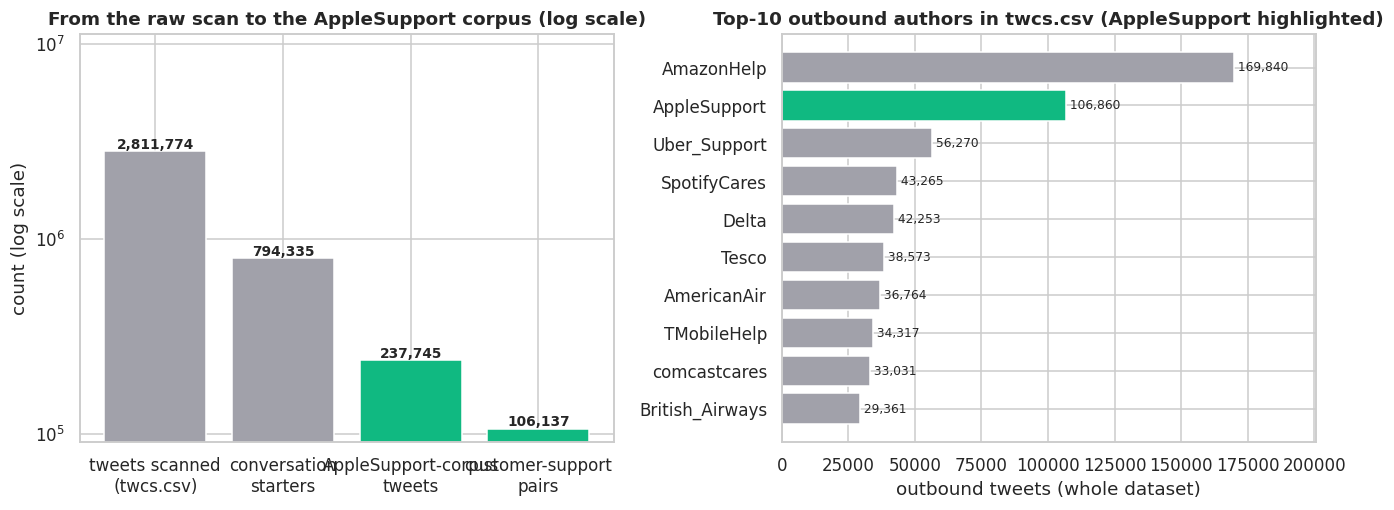

In [7]:
scan = run_report["scan_stats"]
author_totals = {a["author_id"]: a["tweets"] for a in scan["top_outbound_authors"]}

scan_table = pd.DataFrame([
    {"metric": "tweets scanned (whole twcs.csv)", "value": f"{scan['total_rows']:,}"},
    {"metric": "unique tweet ids / duplicate ids", "value": f"{scan['unique_tweet_ids']:,} / {scan['duplicate_tweet_ids']:,}"},
    {"metric": "inbound rows (customers to brands)", "value": f"{scan['inbound_rows']:,}"},
    {"metric": "outbound rows", "value": f"{scan['outbound_rows']:,}"},
    {"metric": "conversation starters", "value": f"{scan['conversation_starters']:,}"},
    {"metric": "malformed inbound flags", "value": f"{scan['malformed_inbound']:,}"},
    {"metric": "columns with missing values", "value": "none" if not scan["missing_by_column"] else str(scan["missing_by_column"])},
    {"metric": "AppleSupport outbound tweets (whole dataset)", "value": f"{author_totals['AppleSupport']:,}"},
    {"metric": "AppleSupport conversations (this corpus)", "value": f"{len(conversations):,}"},
    {"metric": "AppleSupport-corpus tweets", "value": f"{len(tweets):,}"},
    {"metric": "customer-support pairs", "value": f"{len(pairs):,}"},
])
display(scan_table)

apple_share = len(tweets) / scan["total_rows"]
conv_share = len(conversations) / scan["conversation_starters"]
print(f"AppleSupport corpus = {apple_share:.2%} of all scanned tweets")
print(f"Apple conversations = {conv_share:.2%} of all conversation starters in twcs.csv")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

# Left: funnel from the raw scan to the working corpus (log scale).
funnel_labels = ["tweets scanned\n(twcs.csv)", "conversation\nstarters",
                 "AppleSupport-corpus\ntweets", "customer-support\npairs"]
funnel_values = [scan["total_rows"], scan["conversation_starters"], len(tweets), len(pairs)]
bars = axes[0].bar(funnel_labels, funnel_values, color=[NEUTRAL, NEUTRAL, ACCENT, ACCENT])
axes[0].set_yscale("log")
axes[0].set_title("From the raw scan to the AppleSupport corpus (log scale)")
axes[0].set_ylabel("count (log scale)")
axes[0].set_ylim(top=max(funnel_values) * 4)
for bar, value in zip(bars, funnel_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value, f"{value:,}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

# Right: top outbound authors across the whole dataset.
top_authors = scan["top_outbound_authors"][:10]
names = [a["author_id"] for a in top_authors][::-1]
vals = [a["tweets"] for a in top_authors][::-1]
colors = [ACCENT if name == "AppleSupport" else NEUTRAL for name in names]
bars = axes[1].barh(names, vals, color=colors)
axes[1].set_title("Top-10 outbound authors in twcs.csv (AppleSupport highlighted)")
axes[1].set_xlabel("outbound tweets (whole dataset)")
axes[1].set_xlim(0, max(vals) * 1.18)
for bar, value in zip(bars, vals):
    axes[1].text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f" {value:,}",
                 va="center", ha="left", fontsize=8)

fig.tight_layout()
plt.show()

**Observations.**

- The AppleSupport corpus keeps **237,745 of the 2,811,774 scanned tweets (8.46%)** and **80,966 of the 794,335 conversation starters (10.19%)** — a focused but substantial slice.
- `AppleSupport` is the **second-largest support account in the whole dataset** with 106,860 outbound tweets, behind `AmazonHelp` (169,840) and well ahead of `Uber_Support` (56,270). Apple is one of the best-represented brands in twcs — a sound basis for an Apple-focused support agent.
- 106,137 customer↔support pairs is comfortably above the few-thousand-pair scale needed for a Phase 2 golden set and a Phase 3/4 retrieval corpus.

**Implication for evidence retrieval.** The corpus is large enough to treat historical support replies as a retrieval corpus, while small enough (237,745 short texts) that dense-embedding every customer message and support reply in later phases stays cheap.

## 5. Inbound vs outbound distribution

,class,tweets,share
0,inbound (customer tweets),"130,612",54.94%
1,outbound (support side),"107,133",45.06%
2,— authored by @AppleSupport,"106,860",44.95%
3,— authored by other accounts,273,0.11%


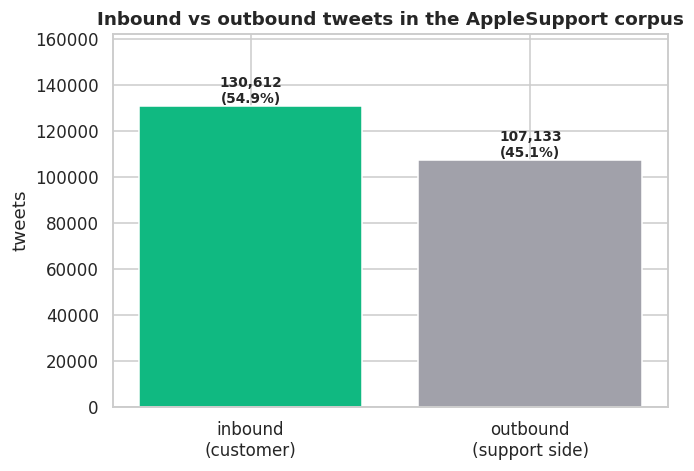

Inbound : outbound = 130,612 : 107,133  (1.22 : 1)
Inbound surplus (customer tweets without an in-corpus Apple reply): 23,479 (9.9% of the corpus)
Extracted pairs cover 81.3% of inbound volume (106,137 pairs / 130,612 inbound tweets; 106,137 unique support replies)
Distinct customer authors: 79,343 (~1.65 inbound tweets per author)


In [8]:
inbound_n = int(tweets["inbound"].sum())
outbound_n = int((~tweets["inbound"]).sum())
apple_authored = int((tweets["author_id"] == "AppleSupport").sum())
other_outbound = outbound_n - apple_authored
customer_authors = int(tweets.loc[tweets["inbound"], "author_id"].nunique())

dist = pd.DataFrame([
    {"class": "inbound (customer tweets)", "tweets": f"{inbound_n:,}", "share": f"{inbound_n / len(tweets):.2%}"},
    {"class": "outbound (support side)", "tweets": f"{outbound_n:,}", "share": f"{outbound_n / len(tweets):.2%}"},
    {"class": "— authored by @AppleSupport", "tweets": f"{apple_authored:,}", "share": f"{apple_authored / len(tweets):.2%}"},
    {"class": "— authored by other accounts", "tweets": f"{other_outbound:,}", "share": f"{other_outbound / len(tweets):.2%}"},
])
display(dist)

fig, ax = plt.subplots(figsize=(6.5, 4.4))
bars = ax.bar(["inbound\n(customer)", "outbound\n(support side)"],
              [inbound_n, outbound_n], color=[ACCENT, NEUTRAL])
ax.set_title("Inbound vs outbound tweets in the AppleSupport corpus")
ax.set_ylabel("tweets")
ax.set_ylim(0, max(inbound_n, outbound_n) * 1.24)
for bar, value in zip(bars, [inbound_n, outbound_n]):
    ax.text(bar.get_x() + bar.get_width() / 2, value,
            f"{value:,}\n({value / len(tweets):.1%})",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.show()

print(f"Inbound : outbound = {inbound_n:,} : {outbound_n:,}  ({inbound_n / outbound_n:.2f} : 1)")
print(f"Inbound surplus (customer tweets without an in-corpus Apple reply): "
      f"{inbound_n - outbound_n:,} ({(inbound_n - outbound_n) / len(tweets):.1%} of the corpus)")
print(f"Extracted pairs cover {len(pairs) / inbound_n:.1%} of inbound volume "
      f"({len(pairs):,} pairs / {inbound_n:,} inbound tweets; "
      f"{pairs['response_tweet_id'].nunique():,} unique support replies)")
print(f"Distinct customer authors: {customer_authors:,} "
      f"(~{inbound_n / customer_authors:.2f} inbound tweets per author)")

**Observations.**

- The split is nearly balanced: **130,612 inbound (54.9%) vs 107,133 outbound (45.1%)** — a 1.22 : 1 ratio.
- Outbound is almost entirely @AppleSupport: **106,860 tweets (45.0% of the corpus)**; only 273 outbound tweets come from other accounts (other brands' agents pulled into the same threads).
- Inbound exceeds outbound by **23,479 tweets (9.9% of the corpus)** — customer messages that never received an AppleSupport reply inside the reconstructed window.
- The 106,137 extracted pairs cover **81.3% of inbound volume** and use 106,137 unique support replies (each reply appears in at most one pair — a pipeline validation).
- **79,343 distinct customer authors** produced the 130,612 inbound tweets (≈ 1.65 inbound tweets per author): mostly one-off customers rather than power users.

**Implication.** Pair-level evidence (one customer message → one historical reply) is abundant. The 23,479 unanswered inbound tweets are unusable as supervised evidence and can be skipped for Phase 2 labelling.

## 6. Conversations & thread-length distribution

Conversations: 80,966
Tweets per conversation — mean 2.94 | median 2 | p75 3 | p90 5 | p95 6 | p99 10 | max 282
Exactly 2 tweets (single exchange)      : 52,673 (65.1%)
Within 4 tweets                        : 71,590 (88.4%)
5+ tweets                              : 9,376 (11.6%)
20+ tweets (tail bucket)               : 95 (0.12%)
Single-tweet conversations (no reply)  : 346

Consistency: sum(customer_tweets)=130,612 == inbound 130,612 and sum(support_tweets)=107,133 == outbound 107,133 -> True


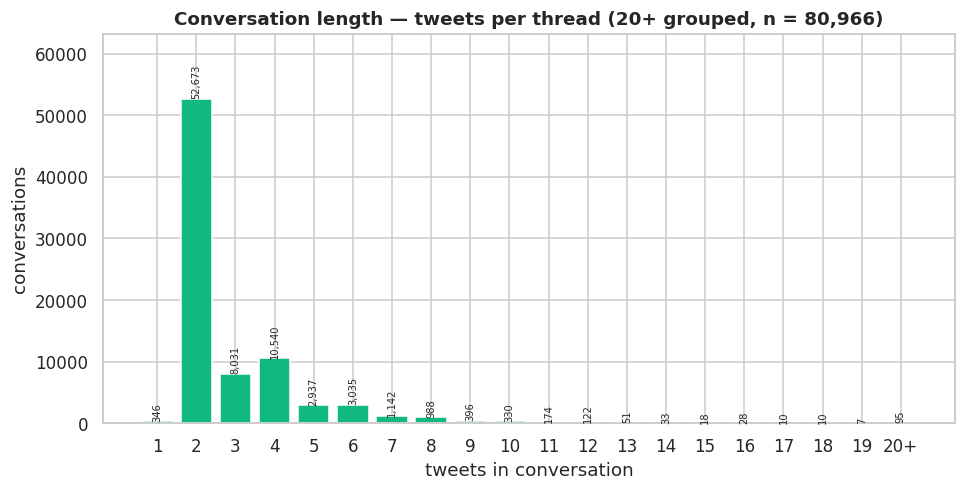

In [9]:
conv_sizes = conversations["tweets"]

print(f"Conversations: {len(conversations):,}")
print(f"Tweets per conversation — mean {conv_sizes.mean():.2f} | median {conv_sizes.median():.0f} | "
      f"p75 {conv_sizes.quantile(0.75):.0f} | p90 {conv_sizes.quantile(0.90):.0f} | "
      f"p95 {conv_sizes.quantile(0.95):.0f} | p99 {conv_sizes.quantile(0.99):.0f} | max {conv_sizes.max()}")
print(f"Exactly 2 tweets (single exchange)      : {(conv_sizes == 2).sum():,} ({(conv_sizes == 2).mean():.1%})")
print(f"Within 4 tweets                        : {(conv_sizes <= 4).sum():,} ({(conv_sizes <= 4).mean():.1%})")
print(f"5+ tweets                              : {(conv_sizes >= 5).sum():,} ({(conv_sizes >= 5).mean():.1%})")
print(f"20+ tweets (tail bucket)               : {(conv_sizes >= 20).sum():,} ({(conv_sizes >= 20).mean():.2%})")
print(f"Single-tweet conversations (no reply)  : {(conv_sizes == 1).sum():,}")

cust_sum = int(conversations["customer_tweets"].astype(int).sum())
supp_sum = int(conversations["support_tweets"].astype(int).sum())
print(f"\nConsistency: sum(customer_tweets)={cust_sum:,} == inbound {inbound_n:,} and "
      f"sum(support_tweets)={supp_sum:,} == outbound {outbound_n:,} "
      f"-> {cust_sum == inbound_n and supp_sum == outbound_n}")

conv_hist = conversation_length_histogram(conversations)
labels = [f"{h['turns']}+" if h["turns"] == CONV_HIST_MAX_TURNS else str(h["turns"])
          for h in conv_hist]
counts = [h["count"] for h in conv_hist]

fig, ax = plt.subplots(figsize=(10, 4.6))
bars = ax.bar(labels, counts, color=ACCENT)
ax.set_title(f"Conversation length — tweets per thread ({CONV_HIST_MAX_TURNS}+ grouped, n = {len(conversations):,})")
ax.set_xlabel("tweets in conversation")
ax.set_ylabel("conversations")
ax.set_ylim(0, max(counts) * 1.20)
for bar, value in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:,}",
            ha="center", va="bottom", fontsize=6.5, rotation=90)
plt.show()

**Observations.**

- **80,966 conversations**; thread length: **median 2 tweets, mean 2.94, max 282** (p75 = 3, p90 = 5, p95 = 6, p99 = 10).
- **65.1% of conversations (52,673) are exactly two tweets** — one customer question plus one AppleSupport reply. **88.4% (71,590) finish within 4 tweets**; only 9,376 (11.6%) run to 5+ tweets and just **95 threads (0.12%) reach 20+ tweets**. 346 conversations contain a single tweet (no reply captured).
- Consistency check: summing the per-conversation `customer_tweets` / `support_tweets` columns yields 130,612 / 107,133 — exactly the inbound / outbound totals, so thread bookkeeping is internally consistent.

**Implication for retrieval evidence (Phase 3/4).** The median exchange is a *single* customer message + reply, so the **pair is the natural retrieval unit**; thread context beyond the immediate pair exists for only a minority of conversations. Long threads are rare but extreme (up to 282 tweets) — any conversation-context enrichment should be windowed (e.g. the last few turns), and escalation research in later phases has only 95 ≥ 20-tweet threads to draw on.

## 7. Message-length statistics

Message length statistics — all 237,745 corpus tweets (cleaned text):


,statistic,characters,words
0,mean,100.8,19.1
1,median,97,18
2,p25,70,13
3,p75,124,23
4,p90,156,30
5,p95,198,37


,bucket (characters),tweets,share
0,1-25,"12,416",5.2%
1,26-50,"20,056",8.4%
2,51-75,"35,986",15.1%
3,76-100,"57,646",24.2%
4,101-150,"85,627",36.0%
5,151-200,"14,669",6.2%
6,201+,"11,345",4.8%


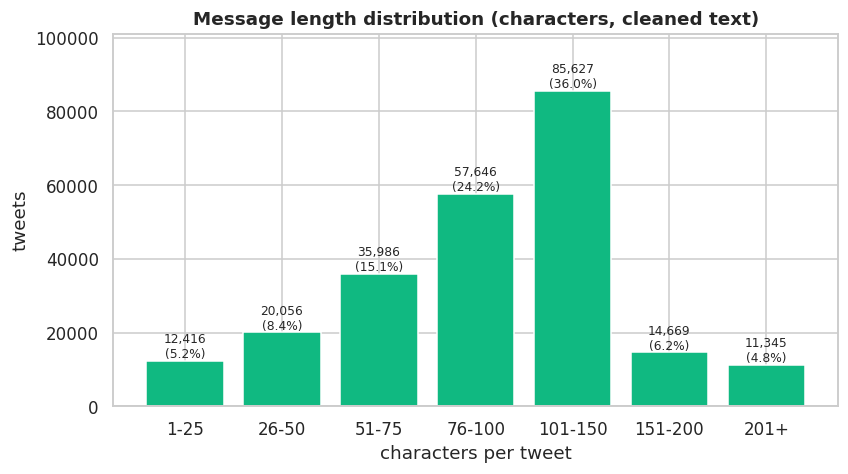

Pair-level lengths (106,137 customer-support pairs):


,side,mean chars,median chars,mean words
0,customer message,97.2,96,18.1
1,support response,108.6,100,20.9


Tweets of at most 200 chars: 226,400 (95.2%) | 201+ chars: 11,345 (4.8%)


In [10]:
texts = tweets["text"].astype(str)
char_len = texts.str.len()
word_len = texts.str.split().str.len()

print(f"Message length statistics — all {len(texts):,} corpus tweets (cleaned text):")
display(pd.DataFrame([
    {"statistic": "mean", "characters": f"{char_len.mean():.1f}", "words": f"{word_len.mean():.1f}"},
    {"statistic": "median", "characters": f"{char_len.median():.0f}", "words": f"{word_len.median():.0f}"},
    {"statistic": "p25", "characters": f"{char_len.quantile(0.25):.0f}", "words": f"{word_len.quantile(0.25):.0f}"},
    {"statistic": "p75", "characters": f"{char_len.quantile(0.75):.0f}", "words": f"{word_len.quantile(0.75):.0f}"},
    {"statistic": "p90", "characters": f"{char_len.quantile(0.90):.0f}", "words": f"{word_len.quantile(0.90):.0f}"},
    {"statistic": "p95", "characters": f"{char_len.quantile(0.95):.0f}", "words": f"{word_len.quantile(0.95):.0f}"},
]))

msg_hist = message_length_histogram(texts)
display(pd.DataFrame([
    {"bucket (characters)": m["bucket"], "tweets": f"{m['count']:,}",
     "share": f"{m['count'] / len(texts):.1%}"}
    for m in msg_hist
]))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
labels = [m["bucket"] for m in msg_hist]
counts = [m["count"] for m in msg_hist]
bars = ax.bar(labels, counts, color=ACCENT)
ax.set_title("Message length distribution (characters, cleaned text)")
ax.set_xlabel("characters per tweet")
ax.set_ylabel("tweets")
ax.set_ylim(0, max(counts) * 1.18)
for bar, m in zip(bars, msg_hist):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{m['count']:,}\n({m['count'] / len(texts):.1%})",
            ha="center", va="bottom", fontsize=8)
plt.show()

cust_chars = pairs["customer_message"].astype(str).str.len()
supp_chars = pairs["support_response"].astype(str).str.len()
cust_words = pairs["customer_message"].astype(str).str.split().str.len()
supp_words = pairs["support_response"].astype(str).str.split().str.len()
print(f"Pair-level lengths ({len(pairs):,} customer-support pairs):")
display(pd.DataFrame([
    {"side": "customer message", "mean chars": f"{cust_chars.mean():.1f}",
     "median chars": f"{cust_chars.median():.0f}", "mean words": f"{cust_words.mean():.1f}"},
    {"side": "support response", "mean chars": f"{supp_chars.mean():.1f}",
     "median chars": f"{supp_chars.median():.0f}", "mean words": f"{supp_words.mean():.1f}"},
]))

print(f"Tweets of at most 200 chars: {(char_len <= 200).sum():,} ({(char_len <= 200).mean():.1%}) | "
      f"201+ chars: {(char_len > 200).sum():,} ({(char_len > 200).mean():.1%})")

**Observations.**

- Across all 237,745 corpus tweets: **mean 100.8 characters / 19.1 words**, median 97 characters / 18 words. Half of all tweets fall between **70 and 124 characters** (IQR); p90 = 156, p95 = 198.
- The modal bucket is **101–150 characters (85,627 tweets, 36.0%)**; 95.2% of tweets are at most 200 characters and 11,345 (4.8%) exceed 200 — consistent with the late-2017 arrival of 280-character tweets.
- Within pairs, historical support replies are slightly longer than customer messages: **108.6 vs 97.2 mean characters** (medians 100 vs 96; 20.9 vs 18.1 mean words).

**Implications.** Messages are compact, self-contained evidence units: whole messages (not fragments) fit trivially into embedding-model context windows, and Phase 5 generation should target tweet-length responses. The customer-vs-support length gap is small enough that symmetric chunking works for retrieval.

## 8. Language of customer messages — terms & bigrams

Computed over the 106,137 customer messages of the pair table, after removing display stopwords **for counting only**.

Counted over 106,137 customer messages (158 display stopwords removed for counting only)



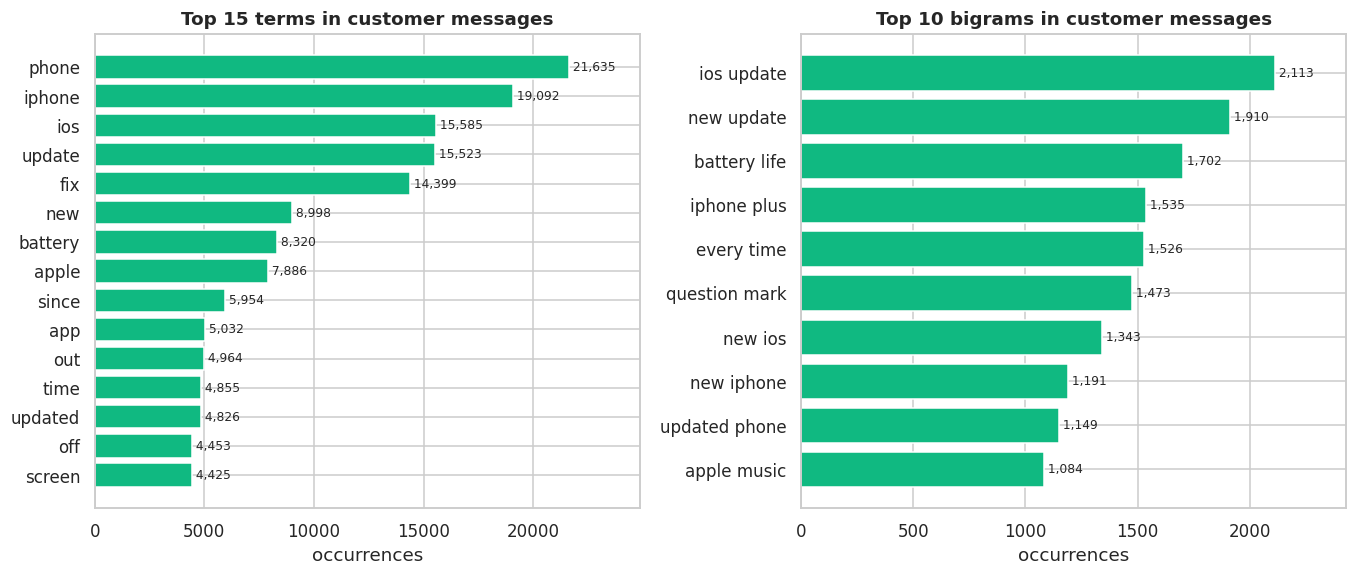

,term,count
0,phone,"21,635"
1,iphone,"19,092"
2,ios,"15,585"
3,update,"15,523"
4,fix,"14,399"
5,new,"8,998"
6,battery,"8,320"
7,apple,"7,886"
8,since,"5,954"
9,app,"5,032"


,bigram,count
0,ios update,"2,113"
1,new update,"1,910"
2,battery life,"1,702"
3,iphone plus,"1,535"
4,every time,"1,526"
5,question mark,"1,473"
6,new ios,"1,343"
7,new iphone,"1,191"
8,updated phone,"1,149"
9,apple music,"1,084"


In [11]:
customer_messages = pairs["customer_message"].astype(str)
top_terms, top_bigrams = term_frequencies(customer_messages)
print(f"Counted over {len(customer_messages):,} customer messages "
      f"({len(STOPWORDS)} display stopwords removed for counting only)\n")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))

axes[0].barh([t["term"] for t in reversed(top_terms)],
             [t["count"] for t in reversed(top_terms)], color=ACCENT)
axes[0].set_title(f"Top {len(top_terms)} terms in customer messages")
axes[0].set_xlabel("occurrences")
axes[0].set_xlim(0, max(t["count"] for t in top_terms) * 1.15)
for bar, item in zip(axes[0].patches, reversed(top_terms)):
    axes[0].text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                 f" {item['count']:,}", va="center", ha="left", fontsize=8)

axes[1].barh([b["term"] for b in reversed(top_bigrams)],
             [b["count"] for b in reversed(top_bigrams)], color=ACCENT)
axes[1].set_title(f"Top {len(top_bigrams)} bigrams in customer messages")
axes[1].set_xlabel("occurrences")
axes[1].set_xlim(0, max(b["count"] for b in top_bigrams) * 1.15)
for bar, item in zip(axes[1].patches, reversed(top_bigrams)):
    axes[1].text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                 f" {item['count']:,}", va="center", ha="left", fontsize=8)

fig.tight_layout()
plt.show()

display(pd.DataFrame([{"term": t["term"], "count": f"{t['count']:,}"} for t in top_terms]))
display(pd.DataFrame([{"bigram": b["term"], "count": f"{b['count']:,}"} for b in top_bigrams]))

**Observations.**

- The customer vocabulary is dominated by **device + software words**: *phone* (21,635), *iphone* (19,092), *ios* (15,585), *update* (15,523), *fix* (14,399), then *new* (8,998), *battery* (8,320), *apple* (7,886), *app* (5,032), *screen* (4,425).
- Bigrams make the intents concrete: **“ios update” (2,113)**, **“new update” (1,910)**, **“battery life” (1,702)**, “iphone plus” (1,535), “every time” (1,526), “new ios” (1,343), “apple music” (1,084). **“question mark” (1,473)** is the trace of the iOS 11.1 autocorrect bug that turned the letter “i” into “?” — it also appears verbatim in one of the sampled conversations below (id 37656).
- Reminder: display stopwords were removed for counting only — the underlying customer text is never modified.

**Implication.** The lexical signal is strongly technical (updates, battery, screen) rather than transactional (billing words are much rarer — see the next section), which anticipates the topic ranking that follows.

## 9. Common support topics — provisional keyword tagging

Each customer message is tagged with every provisional topic whose whole-word keywords it matches (one message can match several). The resulting **class/topic distribution** is the provisional prior for the Phase 2 intent taxonomy.

,topic,matched messages,share of customer messages
0,Software / Apps,"30,740",28.96%
1,Device / Hardware,"15,015",14.15%
2,Connectivity,"2,975",2.80%
3,Billing / Payments,"2,582",2.43%
4,Account / Apple ID,"2,335",2.20%
5,Repair / Warranty,"1,974",1.86%
6,iCloud / Backup,"1,750",1.65%
7,Refunds / Purchases,"1,568",1.48%
8,Order / Delivery,"1,044",0.98%
9,Security / Privacy,631,0.59%


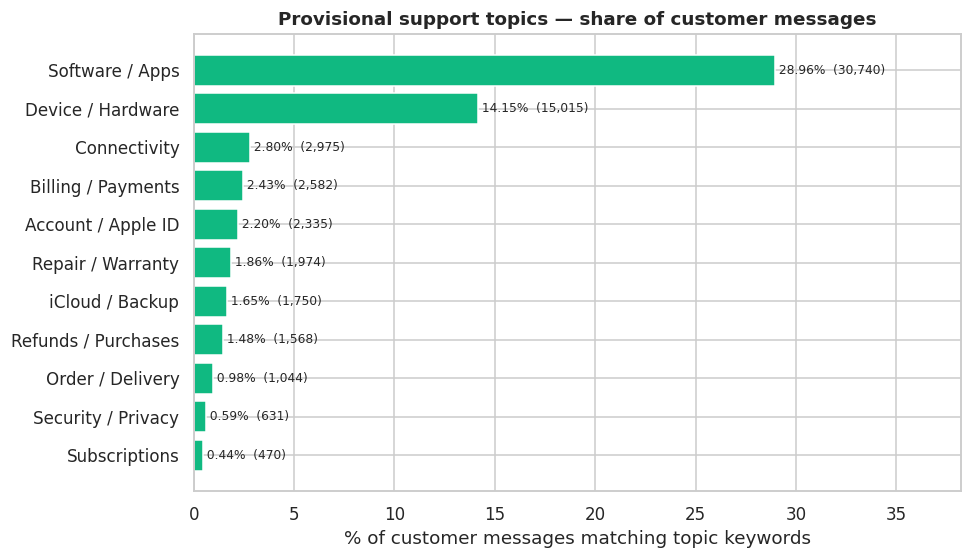

Messages matching at least one topic : 49,613 (46.7%)
Messages matching no topic           : 56,524 (53.3%)
Multi-topic messages (>= 2 topics)   : 10,540 (9.93%)


In [12]:
topics, multi, multi_share, topic_count_hist, co_occurrence = provisional_topics(customer_messages)
total_messages = len(customer_messages)
covered = total_messages - topic_count_hist[0]

display(pd.DataFrame([
    {"topic": t["topic"], "matched messages": f"{t['matched']:,}",
     "share of customer messages": f"{t['share']:.2%}"}
    for t in topics
]))

fig, ax = plt.subplots(figsize=(9, 5.4))
names = [t["topic"] for t in reversed(topics)]
shares = [t["share"] * 100 for t in reversed(topics)]
ax.barh(names, shares, color=ACCENT)
ax.set_title("Provisional support topics — share of customer messages")
ax.set_xlabel("% of customer messages matching topic keywords")
ax.set_xlim(0, max(shares) * 1.32)
for bar, t in zip(ax.patches, reversed(topics)):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f" {t['share']:.2%}  ({t['matched']:,})", va="center", ha="left", fontsize=8)
plt.show()

print(f"Messages matching at least one topic : {covered:,} ({covered / total_messages:.1%})")
print(f"Messages matching no topic           : {topic_count_hist[0]:,} ({topic_count_hist[0] / total_messages:.1%})")
print(f"Multi-topic messages (>= 2 topics)   : {multi:,} ({multi_share:.2%})")

**Observations.**

- **Software / Apps is the dominant provisional topic: 30,740 matches — 28.96%** of the 106,137 customer messages (driven by `update`, `ios`, `app`, `fix` keywords). **Device / Hardware is second with 15,015 (14.15%)**.
- A long gap follows: Connectivity 2,975 (2.80%), Billing / Payments 2,582 (2.43%), Account / Apple ID 2,335 (2.20%), Repair / Warranty 1,974 (1.86%), iCloud / Backup 1,750 (1.65%), Refunds / Purchases 1,568 (1.48%), then the tail: Order / Delivery 1,044 (0.98%), Security / Privacy 631 (0.59%), Subscriptions 470 (0.44%).
- In total **46.7% of customer messages match at least one keyword topic (49,613 messages)**; 53.3% match none. The keyword lists are transparent whole-word matches and therefore conservative — the unmatched majority is not noise, it is signal that a richer taxonomy (Phase 2 labelling) must cover.

**Implication.** These frequencies *inform* the Phase 2 taxonomy — which categories earn a slot and how balanced they can be — but must not be mistaken for ground-truth class priors.

## 10. Multi-topic customer messages

,topics matched,customer messages,share
0,0,"56,524",53.3%
1,1,"39,073",36.8%
2,2,"9,658",9.1%
3,3,834,0.8%
4,4+,48,0.0%


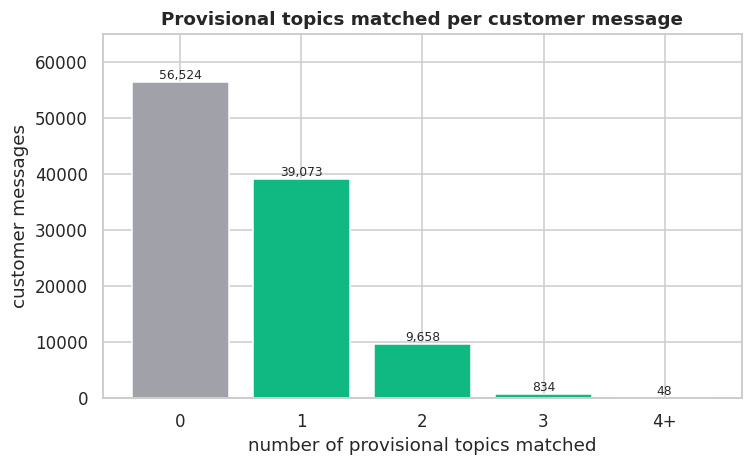

,topic pair,co-occurrences,share of multi-topic messages
0,Device / Hardware × Software / Apps,"5,318",50.5%
1,Connectivity × Software / Apps,963,9.1%
2,Billing / Payments × Software / Apps,636,6.0%
3,Billing / Payments × Device / Hardware,614,5.8%
4,Account / Apple ID × Software / Apps,562,5.3%
5,Software / Apps × iCloud / Backup,458,4.3%
6,Device / Hardware × Repair / Warranty,363,3.4%
7,Connectivity × Device / Hardware,314,3.0%


Multi-topic rate: 10,540 of 106,137 customer messages = 9.93%
Most common overlap: Device / Hardware × Software / Apps — 5,318 co-occurrences (50.5% of multi-topic messages)


In [13]:
display(pd.DataFrame([
    {"topics matched": f"{k}+" if k == 4 else str(k),
     "customer messages": f"{topic_count_hist[k]:,}",
     "share": f"{topic_count_hist[k] / total_messages:.1%}"}
    for k in sorted(topic_count_hist)
]))

fig, ax = plt.subplots(figsize=(7.5, 4.3))
labels = [f"{k}+" if k == 4 else str(k) for k in sorted(topic_count_hist)]
counts = [topic_count_hist[k] for k in sorted(topic_count_hist)]
bars = ax.bar(labels, counts, color=[NEUTRAL, ACCENT, ACCENT, ACCENT, ACCENT])
ax.set_title("Provisional topics matched per customer message")
ax.set_xlabel("number of provisional topics matched")
ax.set_ylabel("customer messages")
ax.set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count:,}",
            ha="center", va="bottom", fontsize=8)
plt.show()

top_co = co_occurrence.most_common(8)
display(pd.DataFrame([
    {"topic pair": " × ".join(pair), "co-occurrences": f"{count:,}",
     "share of multi-topic messages": f"{count / multi:.1%}"}
    for pair, count in top_co
]))

print(f"Multi-topic rate: {multi:,} of {total_messages:,} customer messages = {multi_share:.2%}")
print(f"Most common overlap: {' × '.join(top_co[0][0])} — {top_co[0][1]:,} co-occurrences "
      f"({top_co[0][1] / multi:.1%} of multi-topic messages)")

**Observations.**

- **10,540 customer messages (9.93%) match two or more provisional topics** — roughly one message in ten.
- Topics per message: **0 → 56,524 (53.3%)**, **1 → 39,073 (36.8%)**, **2 → 9,658 (9.1%)**, 3 → 834 (0.8%), 4+ → 48 (0.05%).
- The dominant overlap is **Device / Hardware × Software / Apps with 5,318 co-occurrences — 50.5% of all multi-topic messages**; next come Connectivity × Software / Apps (963), Billing / Payments × Software / Apps (636), Billing / Payments × Device / Hardware (614), Account / Apple ID × Software / Apps (562). This matches intuition: hardware symptoms (“battery”, “screen”) co-occur with software causes (“update”, “ios”).

**Implication for Phase 2.** A single-label classifier would misrepresent ~10% of the traffic. The Phase 2 intent classifier should be **multi-label** (or emit a primary intent plus secondary intents), and the golden set should deliberately include multi-intent examples at roughly this rate.

## 11. Evidence in practice — sample conversations

Six conversations selected deterministically (seed = 42, stratified short / medium / long threads) — the same picks `scripts/run_eda.py` reports in `eda_summary.json`.

In [14]:
samples = sample_conversations(pairs, conversations, seed=SEED)


def clip(text: str, limit: int = 240) -> str:
    text = str(text)
    return text if len(text) <= limit else text[: limit - 1] + "…"


print(f"{len(samples)} deterministic samples (seed = {SEED}): "
      "2 short (<= 3 tweets), 2 medium (4-8 tweets), 2 long (> 8 tweets)\n")
for s in samples:
    print(f"--- conversation {s['conversation_id']} — {s['turns']} tweets — {s['created_at']}")
    print(textwrap.fill(clip(s["customer_message"]), width=96,
                        initial_indent="  customer | ", subsequent_indent="            "))
    print(textwrap.fill(clip(s["support_response"]), width=96,
                        initial_indent="  support  | ", subsequent_indent="            "))
    print()

6 deterministic samples (seed = 42): 2 short (<= 3 tweets), 2 medium (4-8 tweets), 2 long (> 8 tweets)

--- conversation 641999 — 2 tweets — Wed Nov 22 20:13:10 +0000 2017
  customer | My phone has been charging for 2 hours...it’s at 37%. @115858 might be about to
            lose me as a 10 year customer.
  support  | We understand how vital it is to keep your iPhone powered and we want to help.
            Please take a look at this:

--- conversation 2312385 — 2 tweets — Sun Nov 12 21:23:29 +0000 2017
  customer | So many reasons why i cant stand ITunes, spent the past 2 days trying to sort
            everything out on my new phone, itunes enjoys putting videos/pictures on my phone
            that i cant delete from my phone @AppleSupport help before i break something ou…
  support  | We'll be happy to look into this. DM us and we'll go from there.

--- conversation 2278022 — 5 tweets — Sun Nov 12 03:38:42 +0000 2017
  customer | Over wifi
  support  | Got it. Thanks for clarifyin

**Observations.** The samples show the recurring historical support patterns: empathy plus link replies (“Please take a look at this:” — URLs were stripped during cleaning), **deflection to DM** (“DM us and we'll go from there”), and clarifying questions (“Which iOS version is this happening with?”). Conversation 37656 is the iOS 11.1 “i” → “?” autocorrect bug that also surfaces as the “question mark” bigram (1,473 occurrences).

**Implication.** Historical replies are stylistically consistent and short — good few-shot material for Phase 5 prompting — but their advice content is historical (see the disclaimer at the top).

## 12. Cross-check against `scripts/run_eda.py` (`eda_summary.json`)

The pipeline's contract file `data/processed/eda_summary.json` is the single source of truth for the web dashboard. This section proves the notebook computes the same numbers from the same processed CSVs — if any row below were to mismatch, the assertion would fail.

In [15]:
expected = json.loads((DATA_DIR / "eda_summary.json").read_text(encoding="utf-8"))
exp_d = expected["dataset"]

checks: list[dict] = []


def check(name: str, computed, exp) -> None:
    checks.append({"check": name, "notebook value": repr(computed),
                   "eda_summary.json": repr(exp), "match": computed == exp})


check("apple_tweets", int(len(tweets)), int(exp_d["apple_tweets"]))
check("apple_conversations", int(len(conversations)), int(exp_d["apple_conversations"]))
check("support_pairs", int(len(pairs)), int(exp_d["support_pairs"]))
check("apple_inbound", int(inbound_n), int(exp_d["apple_inbound"]))
check("apple_outbound", int(outbound_n), int(exp_d["apple_outbound"]))
check("avg_conversation_turns", round(float(conv_sizes.mean()), 2), float(exp_d["avg_conversation_turns"]))
check("avg_message_chars", round(float(char_len.mean()), 1), float(exp_d["avg_message_chars"]))
check("avg_message_words", round(float(word_len.mean()), 1), float(exp_d["avg_message_words"]))
check("inbound_distribution", {"inbound": int(inbound_n), "outbound": int(outbound_n)},
      expected["inbound_distribution"])
check("conversation_length_histogram", conv_hist, expected["conversation_length_histogram"])
check("message_length_histogram", msg_hist, expected["message_length_histogram"])
check("top_terms", top_terms, expected["top_terms"])
check("top_bigrams", top_bigrams, expected["top_bigrams"])
check("provisional_topics", topics, expected["provisional_topics"])
check("multi_topic_share", multi_share, float(expected["multi_topic_share"]))
check("sample_conversation_ids", [s["conversation_id"] for s in samples],
      [s["conversation_id"] for s in expected["sample_conversations"]])

results = pd.DataFrame(checks)
with pd.option_context("display.max_colwidth", 42, "display.width", 170):
    display(results)

assert bool(results["match"].all()), "Mismatch against eda_summary.json — investigate before trusting this notebook"
print(f"ALL {len(results)} CROSS-CHECKS PASSED — this notebook reproduces "
      "data/processed/eda_summary.json exactly")

,check,notebook value,eda_summary.json,match
0,apple_tweets,237745,237745,True
1,apple_conversations,80966,80966,True
2,support_pairs,106137,106137,True
3,apple_inbound,130612,130612,True
4,apple_outbound,107133,107133,True
5,avg_conversation_turns,2.94,2.94,True
6,avg_message_chars,100.8,100.8,True
7,avg_message_words,19.1,19.1,True
8,inbound_distribution,"{'inbound': 130612, 'outbound': 107133}","{'inbound': 130612, 'outbound': 107133}",True
9,conversation_length_histogram,"[{'turns': 1, 'count': 346}, {'turns':...","[{'turns': 1, 'count': 346}, {'turns':...",True


ALL 16 CROSS-CHECKS PASSED — this notebook reproduces data/processed/eda_summary.json exactly


**Result.** Every notebook-computed statistic matches `eda_summary.json` exactly — the headline dataset metrics, the inbound/outbound distribution, both histograms, the full top-terms and top-bigrams lists, the 11 provisional-topic rows (match counts **and** shares), the multi-topic share, and even the six sample-conversation ids. The notebook and `scripts/run_eda.py` are provably equivalent on this data, and `eda_summary.json` remains the single source of truth consumed by the web dashboard.

## 13. Implications for the Phase 2 intent taxonomy

Every statement below rests on numbers computed in this notebook.

1. **Two headline categories are unambiguous.** Software / Apps (30,740 matches; 28.96% of the 106,137 customer messages) and Device / Hardware (15,015; 14.15%) dominate the traffic. Any Phase 2 taxonomy without both — heavily populated — is wrong for this data; together they account for 45,755 keyword matches (43.1 match-share points before de-overlap).

2. **A well-populated middle tier.** Connectivity (2,975), Billing / Payments (2,582), Account / Apple ID (2,335), Repair / Warranty (1,974), iCloud / Backup (1,750) and Refunds / Purchases (1,568) each have 1.5 k–3 k matches — enough to label a few hundred golden examples per class, but an order of magnitude below the headline pair. Class-imbalance handling (stratified sampling, per-class metrics) must be designed in from the start.

3. **A tail that must merge or be few-shot.** Order / Delivery (1,044; 0.98%), Security / Privacy (631; 0.59%) and Subscriptions (470; 0.44%) are rare. Candidates: fold Subscriptions into a combined billing/subscriptions class, keep Security / Privacy separate despite rarity (it is escalation-relevant), and treat Order / Delivery as a thin class supported by few-shot examples — the final decision belongs to Phase 2 labelling, guided by these counts.

4. **Multi-intent is a hard requirement.** 9.93% of customer messages (10,540) match ≥ 2 topics, and Device × Software alone co-occurs 5,318 times (50.5% of multi-topic messages). The Phase 2 classifier should output multiple intents (primary + secondary), and the golden set should deliberately include multi-intent examples at approximately this rate.

5. **An “Other” class is unavoidable.** 53.3% of messages (56,524) match no provisional keyword. Some of that is small talk and DM deflection, but much of it is genuine demand the keyword lists miss (whole-word matching is conservative). Phase 2 must label a random sample of unmatched messages before freezing the taxonomy — the provisional tags are priors, not ground truth.

6. **Evidence design follows the data.** Median conversation = 2 tweets → retrieve at pair granularity (106,137 pairs available); mean message = 19.1 words → single messages embed whole; support replies average 108.6 characters → generated answers must stay tweet-scale; only 95 conversations have ≥ 20 tweets, delimiting the escalation-study material for later phases.

7. **Historical grounding.** Whatever taxonomy is frozen, the retrieval evidence stays historical: the corpus spans 2013-05-04 → 2017-12-03, with 80% of tweets between 2017-10-10 and 2017-11-26. Historical AppleSupport responses are evidence for retrieval and evaluation, not a representation of current Apple policies.

---

*Notebook `notebooks/01_data_exploration.ipynb` — Phase 1 EDA, executed end-to-end with a Python 3 kernel (outputs embedded). Inputs: `data/processed/{pipeline_run.json, applesupport_tweets.csv, conversations.csv, conversation_pairs.csv, eda_summary.json}`. The raw 516 MB `twcs.csv` was not re-processed. Analysis logic mirrors `scripts/run_eda.py`; reproducible with `SEED = 42`.*